[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-0/basics.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/56295530-getting-set-up-video-guide)

In [1]:
!pip uninstall -y langchain-core langgraph
!pip install -U langchain-core langgraph langchain-deepseek langchain_community
!pip install -U ddgs

Found existing installation: langchain-core 1.3.2
Uninstalling langchain-core-1.3.2:
  Successfully uninstalled langchain-core-1.3.2
Found existing installation: langgraph 1.1.10
Uninstalling langgraph-1.1.10:
  Successfully uninstalled langgraph-1.1.10
  Using cached langchain_core-1.3.2-py3-none-any.whl.metadata (4.4 kB)
  Using cached langgraph-1.1.10-py3-none-any.whl.metadata (8.0 kB)
Using cached langchain_core-1.3.2-py3-none-any.whl (542 kB)
Using cached langgraph-1.1.10-py3-none-any.whl (173 kB)


In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("DEEPSEEK_API_KEY")

DEEPSEEK_API_KEY: ··········


In [3]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from typing_extensions import Literal
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

memory = MemorySaver()

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    summary: str

search_tool = DuckDuckGoSearchRun()
tools = [search_tool]
model = ChatDeepSeek(model="deepseek-chat", temperature=0).bind_tools(tools)

def summarize_conversation(state: AgentState):
    summary = state.get("summary", "")

    if summary:
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"

    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)

    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# 3. Узлы графа
def call_model(state: AgentState):
    messages = state["messages"]

    if state.get("summary"):
        summary_str = f"Краткое содержание предыдущей беседы: {state['summary']}"
        messages = [SystemMessage(content=summary_str)] + messages

    response = model.invoke(state["messages"])
    return {"messages": [response]}

def should_continue(state: AgentState) -> Literal["summarize_conversation", "tools", END]:
    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tools"

    if len(messages) > 6:
        return "summarize_conversation"

    return END

# 4. Сборка графа
workflow = StateGraph(AgentState)


workflow.add_node("summarize_conversation", summarize_conversation)
workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools))

workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", should_continue, {
        "tools": "tools",
        "summarize_conversation":"summarize_conversation",
        END: END
    })
workflow.add_edge("tools", "agent")
workflow.add_edge("summarize_conversation", END)

app = workflow.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "user_2"}}

print("--- Вызов 1 ---")
app.invoke({"messages": [("user", "Меня зовут Максим")]}, config)

print("--- Вызов 2 ---")
response = app.invoke({"messages": [("user", "Как меня зовут?")]}, config)

print("\nОТВЕТ АГЕНТА:")
print(response["messages"][-1].content)

--- Вызов 1 ---
--- Вызов 2 ---

ОТВЕТ АГЕНТА:
Тебя зовут Максим! Ты сам мне это сказал в начале разговора. 😊

Чем могу ещё помочь?


In [4]:
response = app.invoke({"messages": [("user", "Какой прогноз погоды в долгопрудном на сегодня")]}, config)

print("\nОТВЕТ АГЕНТА:")
print(response["messages"][-1].content)


ОТВЕТ АГЕНТА:
По данным поиска, вот прогноз погоды в Долгопрудном на сегодня (среда, 29 апреля 2026 года):

- **Восход солнца**: 04:51
- **Заход солнца**: 20:05

К сожалению, точные данные о температуре, осадках и ветре не отобразились в результатах поиска. Рекомендую заглянуть на сайты типа Gismeteo, Yandex.Погода или Meteoweb для получения более детальной информации по часам. 

Хочешь, чтобы я поискал более подробный прогноз?


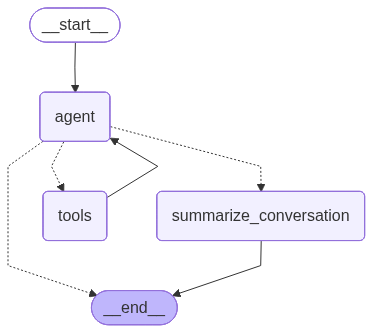

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))